# Project 3 Exercise: NIR Image Classification Using XCT Labels

In this guided exercise, you will train a Convolutional Neural Network (CNN) to classify whole-part NIR images into two classes:

* **No XCT flaw**
* **XCT flaw**

The input image is a cropped NIR image of one printed part at one build layer. The label comes from post-build XCT inspection.

Some code cells are complete, and some parts are left as **TODO** sections for you to fill in.


## 1. Mount Google Drive and set file paths

First, we mount Google Drive so the notebook can access the project data files.

For this project, we only need two files:

1. `project3_nir_xct_labels_balanced.npz`
2. `project3_nir_metadata_balanced.csv`

Both files should be stored in the same Google Drive folder.  
Only the `PROJECT_FOLDER` path needs to be changed if the files are stored somewhere else.

In [ ]:
# ============================================================
# Cell 1: Mount Google Drive and set file paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os

# TODO: Change this folder path if your files are stored somewhere else
PROJECT_FOLDER = Path("/content/drive/MyDrive/Colab_Notebooks/SUPREME_2026/Project_03")

# These are the two required files
NPZ_PATH = PROJECT_FOLDER / "project3_nir_xct_labels_balanced.npz"
META_PATH = PROJECT_FOLDER / "project3_nir_metadata_balanced.csv"

print("Project folder:", PROJECT_FOLDER)
print("NPZ file exists:", NPZ_PATH.exists())
print("Metadata CSV exists:", META_PATH.exists())

if not NPZ_PATH.exists():
    raise FileNotFoundError(f"Could not find NPZ file at: {NPZ_PATH}")

if not META_PATH.exists():
    raise FileNotFoundError(f"Could not find metadata CSV file at: {META_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/Colab_Notebooks/SUPREME_2026/Project_03
NPZ file exists: True
Metadata CSV exists: True


## 2. Load the Project 3 dataset

The main data is stored in a compressed NumPy file, or `.npz` file.

This file contains:

- `X`: NIR image crops
- `y`: class labels
- `flaw_mask`: XCT flaw masks for visualization

The metadata CSV contains information about each image, such as the part ID, layer number, and number of XCT flaw pixels.

In [ ]:
# ============================================================
# Cell 2: Load Project 3 dataset
# ============================================================

import numpy as np
import pandas as pd

# TODO: Load the NPZ file using np.load()
data = np.load(____)

# TODO: Extract X, y, and flaw_mask from the NPZ file
X = data["____"]
y = data["____"]
flaw_mask = data["____"]

# TODO: Load the metadata CSV using pandas
df_meta = pd.read_csv(____)

print("Dataset loaded successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("flaw_mask shape:", flaw_mask.shape)

print("\nClass counts:")
print(pd.Series(y).map({0: "No XCT flaw", 1: "XCT flaw"}).value_counts())

display(df_meta.head())


Dataset loaded successfully.
X shape: (240, 128, 128)
y shape: (240,)
flaw_mask shape: (240, 128, 128)

Class counts:
No XCT flaw    120
XCT flaw       120
Name: count, dtype: int64


,layer,part_id,label,label_name,flaw_pixels_in_part_crop,original_crop_height,original_crop_width,sample_id
0,400,19,0,No XCT flaw,0,233,233,0
1,650,51,1,XCT flaw,286,233,233,1
2,100,64,0,No XCT flaw,0,232,232,2
3,450,13,0,No XCT flaw,0,233,232,3
4,400,14,0,No XCT flaw,0,233,232,4


## 3. Visualize the NIR image crops

Before training a model, we should always look at the data.

Each image shown below is a cropped NIR view of one printed part at one build layer.

The top row shows examples labeled as **XCT flaw**.  
The bottom row shows examples labeled as **No XCT flaw**.

The visual difference may not always be obvious because XCT flaws are post-build internal inspection labels.

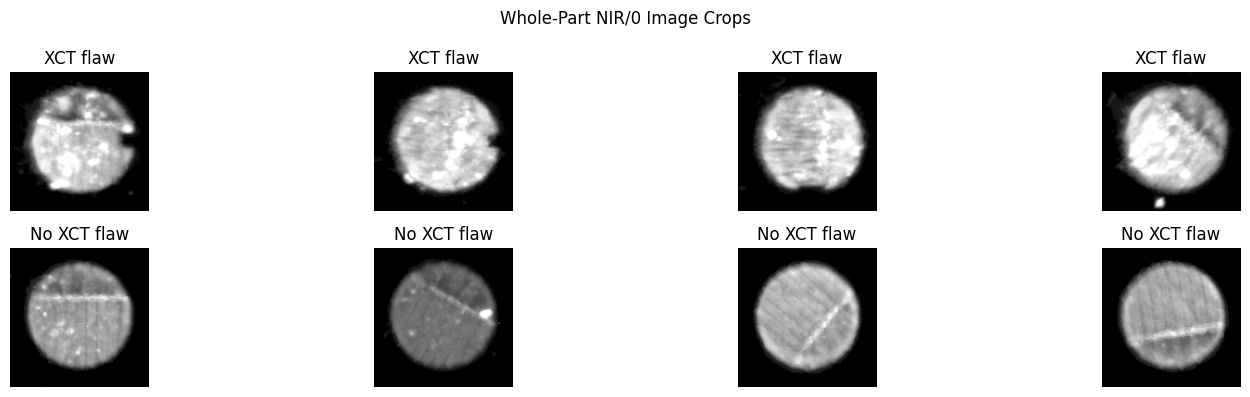

In [ ]:
# ============================================================
# Cell 3: Visualize sample NIR images
# ============================================================

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_show = 4

# TODO: Find indices for flaw and no-flaw samples
flaw_indices = np.where(y == ____)[0]
no_flaw_indices = np.where(y == ____)[0]

chosen_flaw = rng.choice(flaw_indices, size=n_show, replace=False)
chosen_no_flaw = rng.choice(no_flaw_indices, size=n_show, replace=False)

plt.figure(figsize=(16, 4))

for i, idx in enumerate(chosen_flaw):
    plt.subplot(2, n_show, i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.title("XCT flaw")
    plt.axis("off")

for i, idx in enumerate(chosen_no_flaw):
    plt.subplot(2, n_show, n_show + i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.title("No XCT flaw")
    plt.axis("off")

plt.suptitle("Whole-Part NIR Image Crops")
plt.tight_layout()
plt.show()


## 4. Visualize XCT flaw overlays

The red overlay shows the XCT flaw mask for selected flaw examples.

The grayscale image is the NIR input image.  
The red region is the XCT-based flaw label.

The CNN will only use the grayscale NIR image as input.  
The XCT mask is used to create the label and to help us understand where the flaw was detected.

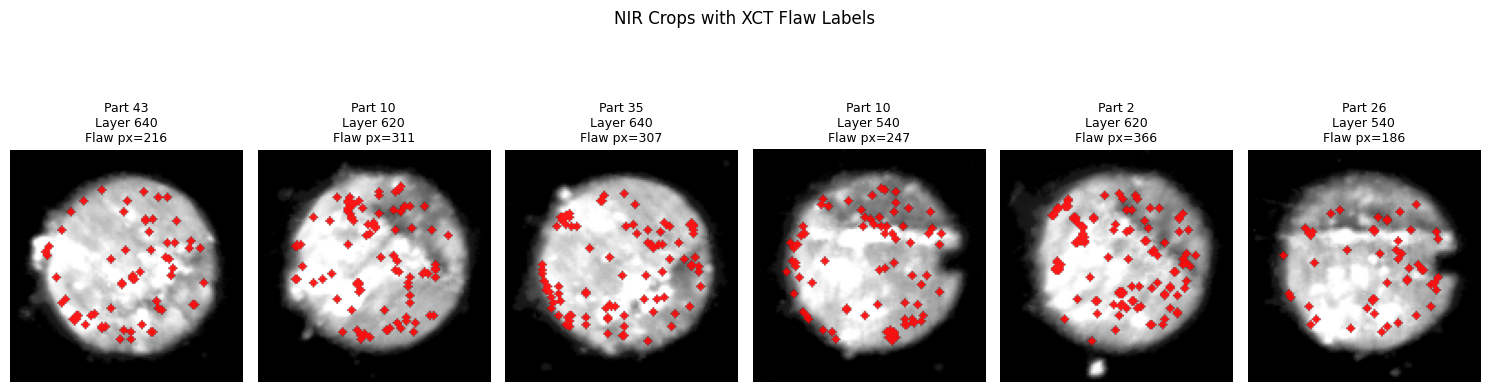

In [ ]:
# ============================================================
# Cell 4: Visualize XCT flaw overlays
# ============================================================

from scipy.ndimage import binary_dilation

n_show = 6
chosen = rng.choice(flaw_indices, size=n_show, replace=False)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(chosen):
    # Dilate the flaw mask only for visualization
    overlay = binary_dilation(flaw_mask[idx].astype(bool), iterations=2)
    overlay = np.ma.masked_where(~overlay, overlay)

    plt.subplot(1, n_show, i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.imshow(overlay, cmap="autumn", alpha=0.9)

    part_id = df_meta.loc[idx, "part_id"]
    layer = df_meta.loc[idx, "layer"]
    flaw_pixels = df_meta.loc[idx, "flaw_pixels_in_part_crop"]

    plt.title(f"Part {part_id}\nLayer {layer}\nFlaw px={flaw_pixels}", fontsize=9)
    plt.axis("off")

plt.suptitle("NIR Crops with XCT Flaw Labels")
plt.tight_layout()
plt.show()


## 5. Split the dataset into training and testing sets

We split the dataset into two parts:

- **Training set:** used to train the CNN
- **Testing set:** used to evaluate the CNN on unseen data

We use a stratified split so that both classes are balanced in the training and testing sets.

In [ ]:
# ============================================================
# Cell 5: Train/test split
# ============================================================

from sklearn.model_selection import train_test_split

indices = np.arange(len(y))

# TODO: Use train_test_split to create train_idx and test_idx
# Hint:
# - test_size should be 0.25
# - random_state should be 42
# - use stratify=y
train_idx, test_idx = train_test_split(
    ____,
    test_size=____,
    random_state=____,
    stratify=____
)

# TODO: Use the indices to create training and testing arrays
X_train = X[____]
y_train = y[____]

X_test = X[____]
y_test = y[____]

meta_train = df_meta.iloc[train_idx].reset_index(drop=True)
meta_test = df_meta.iloc[test_idx].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain class counts:")
print(pd.Series(y_train).map({0: "No XCT flaw", 1: "XCT flaw"}).value_counts())

print("\nTest class counts:")
print(pd.Series(y_test).map({0: "No XCT flaw", 1: "XCT flaw"}).value_counts())


X_train: (180, 128, 128)
X_test: (60, 128, 128)

Train class counts:
XCT flaw       90
No XCT flaw    90
Name: count, dtype: int64

Test class counts:
XCT flaw       30
No XCT flaw    30
Name: count, dtype: int64


## 6. Normalize the image data

Neural networks usually train better when input values are normalized.

We calculate the mean and standard deviation from the training images only.  
Then we use the same values to normalize both the training and testing images.

This avoids using information from the test set during training.

In [ ]:
# ============================================================
# Cell 6: Normalize image data
# ============================================================

# TODO: Calculate mean and standard deviation from training data only
train_mean = X_train.____()
train_std = X_train.____() + 1e-8

# TODO: Normalize train and test images
X_train_norm = (X_train - ____) / ____
X_test_norm = (X_test - ____) / ____

print("Training mean:", train_mean)
print("Training std:", train_std)

print("\nAfter normalization:")
print("X_train_norm mean:", X_train_norm.mean())
print("X_train_norm std:", X_train_norm.std())


Training mean: 0.2799436
Training std: 0.3267689

After normalization:
X_train_norm mean: -3.2103725e-07
X_train_norm std: 1.0000004


## 7. Create PyTorch Dataset and DataLoader

PyTorch needs the data in a specific format for training.

In this step, we create:

- a custom dataset class
- a training data loader
- a testing data loader

The data loader gives images to the CNN in small batches instead of all at once.

In [ ]:
# ============================================================
# Cell 7: PyTorch Dataset and DataLoader
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class WholePartDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):
        # TODO: return the number of samples
        return len(____)

    def __getitem__(self, idx):
        # TODO: convert one image and one label into tensors
        # Hint: image should have shape (1, 128, 128)
        image = torch.tensor(self.X[idx][None, :, :], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.float32)
        return image, label


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

# TODO: Create train_loader and test_loader
train_loader = DataLoader(
    WholePartDataset(____, ____),
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    WholePartDataset(____, ____),
    batch_size=16,
    shuffle=False
)


Using device: cuda


## 8. Define the CNN model

A Convolutional Neural Network, or CNN, is commonly used for image classification.

This CNN takes one grayscale NIR image as input.  
The image size is `128 × 128`.

The model outputs one score:

- low score → likely **No XCT flaw**
- high score → likely **XCT flaw**

The model includes convolution layers, batch normalization, pooling layers, dropout, and a final classification layer.

In [ ]:
# ============================================================
# Cell 8: Define CNN model
# ============================================================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # TODO: First convolution block
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            # TODO: Second convolution block
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            # TODO: Third convolution block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            # Final feature block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            # TODO: final linear layer should output 1 value
            nn.Linear(____, ____)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


# TODO: Create model, loss function, and optimizer
model = CNN().to(device)

criterion = nn.____()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(model)


CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14)

## 9. Train the CNN

Now we train the CNN using the training images.

During training, the model tries to reduce the classification loss and improve accuracy.

For each epoch, we print:

- training loss
- training accuracy

The loss should generally decrease over time, while accuracy should generally improve.

In [ ]:
# ============================================================
# Cell 9: Train CNN
# ============================================================

num_epochs = 30

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # TODO: Clear old gradients
        optimizer.____()

        # TODO: Forward pass
        logits = model(____)
        loss = criterion(____, ____)

        # TODO: Backpropagation and optimizer step
        loss.____()
        optimizer.____()

        total_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.4f}"
    )


Epoch [01/30] Loss: 0.4355 | Accuracy: 0.8444
Epoch [02/30] Loss: 0.3638 | Accuracy: 0.8611
Epoch [03/30] Loss: 0.3636 | Accuracy: 0.8833
Epoch [04/30] Loss: 0.3640 | Accuracy: 0.8722
Epoch [05/30] Loss: 0.3224 | Accuracy: 0.8889
Epoch [06/30] Loss: 0.3107 | Accuracy: 0.8944
Epoch [07/30] Loss: 0.3260 | Accuracy: 0.8667
Epoch [08/30] Loss: 0.3099 | Accuracy: 0.9000
Epoch [09/30] Loss: 0.3326 | Accuracy: 0.8833
Epoch [10/30] Loss: 0.2788 | Accuracy: 0.8944
Epoch [11/30] Loss: 0.2498 | Accuracy: 0.9222
Epoch [12/30] Loss: 0.2813 | Accuracy: 0.9056
Epoch [13/30] Loss: 0.2719 | Accuracy: 0.9111
Epoch [14/30] Loss: 0.2345 | Accuracy: 0.9167
Epoch [15/30] Loss: 0.2237 | Accuracy: 0.9389
Epoch [16/30] Loss: 0.2538 | Accuracy: 0.9167
Epoch [17/30] Loss: 0.2425 | Accuracy: 0.9222
Epoch [18/30] Loss: 0.2090 | Accuracy: 0.9111
Epoch [19/30] Loss: 0.2225 | Accuracy: 0.9389
Epoch [20/30] Loss: 0.1909 | Accuracy: 0.9389
Epoch [21/30] Loss: 0.1778 | Accuracy: 0.9333
Epoch [22/30] Loss: 0.2222 | Accur

## 10. Plot the training curves

Training curves help us understand how the model learned over time.

We plot:

- training loss versus epoch
- training accuracy versus epoch

These plots help us check whether the model is learning properly.

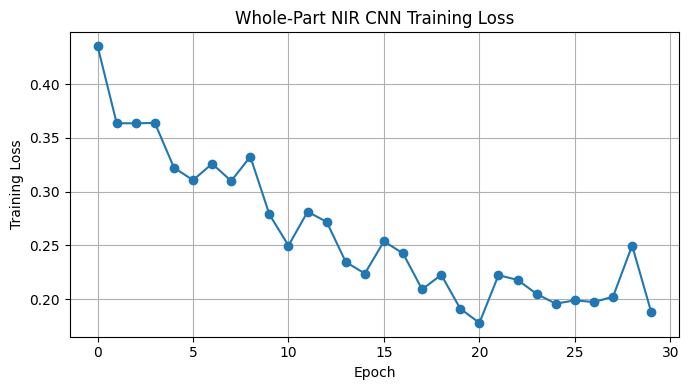

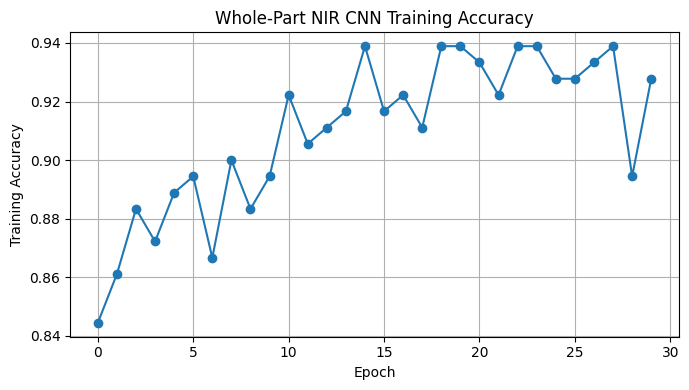

In [ ]:
# ============================================================
# Cell 10: Plot training curves
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Whole-Part NIR CNN Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Whole-Part NIR CNN Training Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Evaluate the CNN on the test set

After training, we evaluate the model on the test set.

The test set contains images the model did not see during training.

We report:

- test accuracy
- precision
- recall
- F1-score
- confusion matrix

The confusion matrix shows how many images were correctly or incorrectly classified.

Test accuracy: 0.9666666666666667

              precision    recall  f1-score   support

 No XCT flaw       1.00      0.93      0.97        30
    XCT flaw       0.94      1.00      0.97        30

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



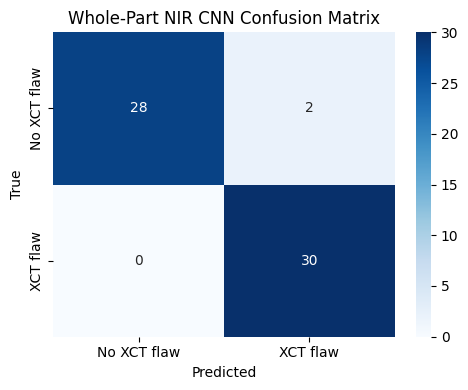

In [ ]:
# ============================================================
# Cell 11: Evaluate CNN
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

model.eval()

all_probabilities = []
all_predictions = []
all_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # TODO: Get logits from model
        logits = model(____)

        probabilities = torch.sigmoid(logits).cpu().numpy()
        predictions = (probabilities >= 0.5).astype(int)

        all_probabilities.extend(probabilities)
        all_predictions.extend(predictions)
        all_true.extend(labels.numpy().astype(int))

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_true = np.array(all_true)

accuracy = accuracy_score(all_true, all_predictions)

print("Test accuracy:", accuracy)
print()

print(classification_report(
    all_true,
    all_predictions,
    target_names=["No XCT flaw", "XCT flaw"],
    zero_division=0
))

cm = confusion_matrix(all_true, all_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No XCT flaw", "XCT flaw"],
    yticklabels=["No XCT flaw", "XCT flaw"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Whole-Part NIR CNN Confusion Matrix")
plt.tight_layout()
plt.show()


## Final discussion

In this project, we trained a CNN to classify NIR image crops using XCT-based labels.

The key workflow was:

1. Load the curated NIR/XCT dataset
2. Visualize the image crops and XCT labels
3. Split the data into train and test sets
4. Normalize the images
5. Train a CNN
6. Evaluate the model with a confusion matrix and classification report

This project shows how in-situ manufacturing images can be connected to post-build inspection data.

However, we should interpret the result carefully. The CNN is not directly seeing internal defects. Instead, it learns NIR image patterns that are statistically associated with XCT-detected flaw regions.